---
Author: The Tuan Trinh \
Date: 2026-05-30
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: posix
System: Linux
Release: 6.6.122+
Machine: x86_64
Processor: x86_64
Platform: Linux-6.6.122+-x86_64-with-glibc2.35

Environment Variables (sample):
SHELL = /bin/bash
COLAB_JUPYTER_TRANSPORT = ipc
CGROUP_MEMORY_EVENTS = /sys/fs/cgroup/memory.events /var/colab/cgroup/jupyter-children/memory.events
VM_GCE_METADATA_HOST = 169.254.169.253
MODEL_PROXY_HOST = https://mp.kaggle.net
HOSTNAME = 81f94d2e7c78
LANGUAGE = en_US
TBE_RUNTIME_ADDR = 172.28.0.1:8011
GCE_METADATA_TIMEOUT = 3
COLAB_JUPYTER_IP = 172.28.0.12
KMP_LISTEN_PORT = 6000
TF_FORCE_GPU_ALLOW_GROWTH = true
ENV = /root/.bashrc
PWD = /
TBE_EPHEM_CREDS_ADDR = 172.28.0.1:8009


In [2]:
platform.python_version()

'3.12.13'

# LAB 7: Image Gradients

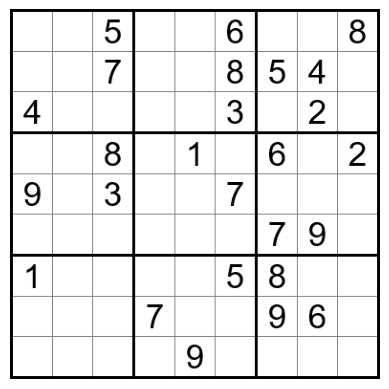

In [3]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

url = "https://www.puzzles.ca/sudoku_puzzles_images/sudoku_easy_1060.gif"
resp = urllib.request.urlopen(url)
img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_pil = Image.open(io.BytesIO(img))
plt.imshow(img_pil)
plt.axis("off")
plt.show()

## CV2 Lib

(Text(0.5, 1.0, 'Sobel Y'), ([], []), ([], []))

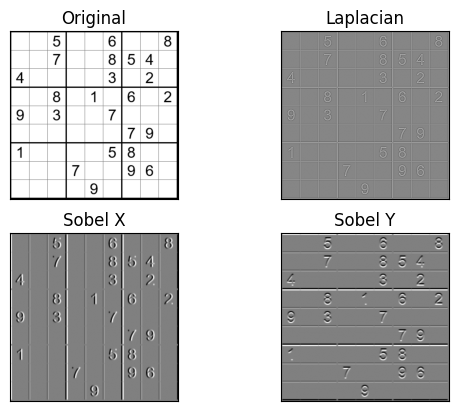

In [4]:
import cv2

img_np = np.array(img_pil, dtype=np.uint8)

laplacian = cv2.Laplacian(img_np,cv2.CV_64F)
sobelx = cv2.Sobel(img_np,cv2.CV_64F,1,0,ksize=5)
sobely = cv2.Sobel(img_np,cv2.CV_64F,0,1,ksize=5)

plt.subplot(2,2,1),plt.imshow(img_np,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,2),plt.imshow(laplacian,cmap = 'gray')
plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,3),plt.imshow(sobelx,cmap = 'gray')
plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,4),plt.imshow(sobely,cmap = 'gray')
plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])

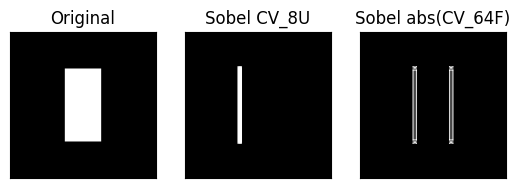

In [5]:
import numpy as np
bitmap = np.zeros((128, 128), dtype=np.uint8)
bitmap[32:96, 48:80] = 220

# Output dtype = cv.CV_8U
sobelx8u = cv2.Sobel(bitmap,cv2.CV_8U,1,0,ksize=5)

# Output dtype = cv.CV_64F. Then take its absolute and convert to cv.CV_8U
sobelx64f = cv2.Sobel(bitmap,cv2.CV_64F,1,0,ksize=5)
abs_sobel64f = np.absolute(sobelx64f)
sobel_8u = np.uint8(abs_sobel64f)

plt.subplot(1,3,1),plt.imshow(bitmap,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,2),plt.imshow(sobelx8u,cmap = 'gray')
plt.title('Sobel CV_8U'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,3),plt.imshow(sobel_8u,cmap = 'gray')
plt.title('Sobel abs(CV_64F)'), plt.xticks([]), plt.yticks([])

plt.show()